In [ ]:
"""
Training deep learning models for too long on the same data can lead to overfitting where the model performs well on training data but poorly on unseen data.
Dropout Regularization helps overcome this by randomly deactivating a portion of neurons during training hence forcing the model to learn more robust and independent
features.
"""

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Dataset & DataLoaders

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_set, val_set = random_split(train_full, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=100, shuffle=True)
val_loader = DataLoader(val_set, batch_size=100, shuffle=False)
test_loader = DataLoader(test_set, batch_size=100, shuffle=False)

In [4]:
# Define Model Without Dropout

class CNN_NoDropout(nn.Module):
    def __init__(self):
        super(CNN_NoDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [5]:
# Define Model With Dropout

class CNN_WithDropout(nn.Module):
    def __init__(self, p=0.5):
        super(CNN_WithDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=p)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


In [6]:
# Training and validation

def train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs=10, device='cpu'):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    model.to(device)
    for epoch in range(epochs):
        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        model.eval()
        total, correct, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100 * correct / total)

        print(f"Epoch [{epoch+1}/{epochs}] Train Acc: {train_accs[-1]:.2f}% Val Acc: {val_accs[-1]:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

In [7]:
# Instantiate models and train

epochs = 10
device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.CrossEntropyLoss()

model_no = CNN_NoDropout().to(device)
opt_no = optim.SGD(model_no.parameters(), lr=0.01, momentum=0.9)
loss_no_train, loss_no_val, acc_no_train, acc_no_val = train_and_validate(
    model_no, train_loader, val_loader, opt_no, criterion, epochs, device
)

model_do = CNN_WithDropout(p=0.5).to(device)
opt_do = optim.SGD(model_do.parameters(), lr=0.01, momentum=0.9)
loss_do_train, loss_do_val, acc_do_train, acc_do_val = train_and_validate(
    model_do, train_loader, val_loader, opt_do, criterion, epochs, device
)

Epoch [1/10] Train Acc: 88.85% Val Acc: 97.34%
Epoch [2/10] Train Acc: 97.80% Val Acc: 98.05%
Epoch [3/10] Train Acc: 98.38% Val Acc: 98.40%
Epoch [4/10] Train Acc: 98.80% Val Acc: 98.53%
Epoch [5/10] Train Acc: 98.98% Val Acc: 98.66%
Epoch [6/10] Train Acc: 99.19% Val Acc: 98.59%
Epoch [7/10] Train Acc: 99.29% Val Acc: 98.59%
Epoch [8/10] Train Acc: 99.43% Val Acc: 98.52%
Epoch [9/10] Train Acc: 99.54% Val Acc: 98.93%
Epoch [10/10] Train Acc: 99.66% Val Acc: 98.84%
Epoch [1/10] Train Acc: 83.22% Val Acc: 96.97%
Epoch [2/10] Train Acc: 96.23% Val Acc: 97.72%
Epoch [3/10] Train Acc: 97.41% Val Acc: 98.35%
Epoch [4/10] Train Acc: 97.92% Val Acc: 98.46%
Epoch [5/10] Train Acc: 98.10% Val Acc: 98.66%
Epoch [6/10] Train Acc: 98.40% Val Acc: 98.76%
Epoch [7/10] Train Acc: 98.56% Val Acc: 98.70%
Epoch [8/10] Train Acc: 98.62% Val Acc: 98.66%
Epoch [9/10] Train Acc: 98.80% Val Acc: 98.83%
Epoch [10/10] Train Acc: 98.85% Val Acc: 98.81%


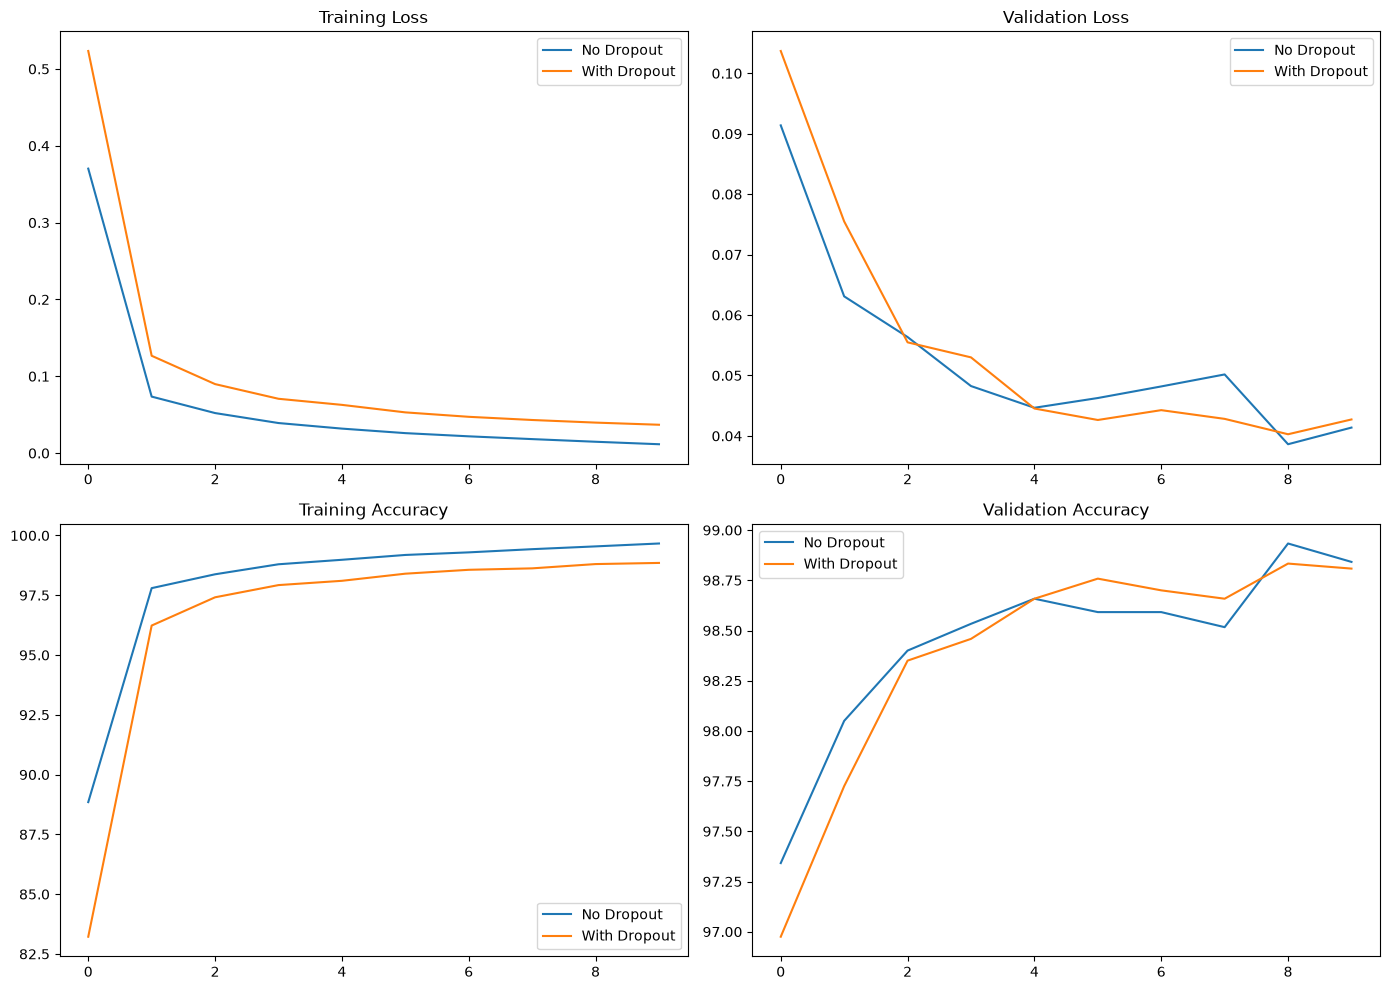

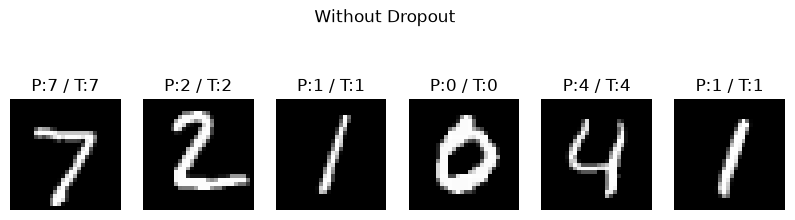

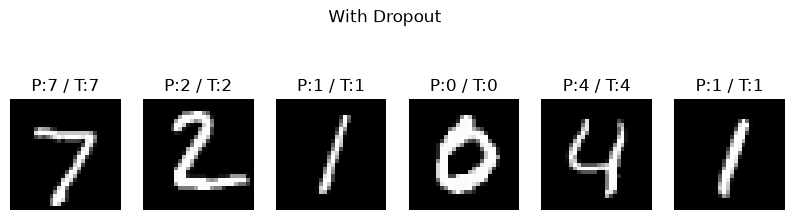

In [8]:
# Visualize training curves & sample predictions

plt.figure(figsize=(14,10))
plt.subplot(2,2,1); plt.plot(loss_no_train, label='No Dropout'); plt.plot(loss_do_train, label='With Dropout'); plt.title('Training Loss'); plt.legend()
plt.subplot(2,2,2); plt.plot(loss_no_val, label='No Dropout'); plt.plot(loss_do_val, label='With Dropout'); plt.title('Validation Loss'); plt.legend()
plt.subplot(2,2,3); plt.plot(acc_no_train, label='No Dropout'); plt.plot(acc_do_train, label='With Dropout'); plt.title('Training Accuracy'); plt.legend()
plt.subplot(2,2,4); plt.plot(acc_no_val, label='No Dropout'); plt.plot(acc_do_val, label='With Dropout'); plt.title('Validation Accuracy'); plt.legend()
plt.tight_layout(); plt.show()
def visualize_predictions(model, loader, title, device='cpu', n=6):
    model.to(device); model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(10,3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i].cpu().squeeze()
        plt.imshow(img, cmap='gray')
        plt.title(f"P:{preds[i].item()} / T:{labels[i].item()}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

visualize_predictions(model_no, test_loader, "Without Dropout", device)
visualize_predictions(model_do, test_loader, "With Dropout", device)
